# AI Agents for Report Generation
Nojood alnahdi

This project demonstrates a multi-agent AI system using LangGraph and Groq.

The system includes:
- Research Agent
- Summary Agent
- Writing Agent
- Review Agent
- Report Manager (LangGraph)



In [1]:
!pip install -q langchain
!pip install -q langgraph
!pip install -q langchain-community
!pip install -q langchain-groq
!pip install -q tavily-python
!pip install -q python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 1.7 MB/s eta 0:00:00


In [2]:
import os

from typing import TypedDict

from langgraph.graph import StateGraph, START, END

from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

from IPython.display import Image, display

/tmp/ipykernel_2525/3725401576.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [3]:
os.environ["GROQ_API_KEY"] = "API KEY" ##llm

os.environ["TAVILY_API_KEY"] = "API KEY" #search

In [4]:
#initialize llm
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

search = TavilySearchResults(max_results=5)#Initialize Tavily Search Tool

/tmp/ipykernel_2525/3957401552.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=5)


In [7]:
#test llm
response = llm.invoke("Say hello in one sentence.")

print(response.content)

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [8]:
#test search tool
results = search.invoke("Latest AI trends")

print(results)

[{'title': 'Five Trends in AI and Data Science for 2026', 'url': 'https://sloanreview.mit.edu/article/five-trends-in-ai-and-data-science-for-2026', 'content': 'Share\n\nTwitter Facebook Linkedin  Copy Link\n\n \n\nCarolyn Geason-Beissel/MIT SMR | Getty Images\n\nSummary: \n\nMIT SMR columnists Thomas H. Davenport and Randy Bean see five AI trends to pay attention to in 2026: deflation of the AI bubble and subsequent hits to the economy; growth of the “factory” infrastructure for all-in AI adapters; greater focus on generative AI as an organizational resource rather than an individual one; continued progression toward value from agentic AI, despite the hype; and ongoing questions around who should manage data and AI.', 'score': 0.8440111}, {'title': '12+ AI Trends Businesses Must Watch in 2026', 'url': 'https://appinventiv.com/blog/ai-trends', 'content': 'As AI does not seem to stop its growing prevalence in near future, several key trends are emerging to reinforce AI’s capabilities and

**create state**

In [9]:
from typing import TypedDict

class ReportState(TypedDict):
    topic: str
    research_notes: str
    summary: str
    draft_report: str
    final_report: str

**1st agent**
## Research Agent
Collects information from Tavily and prepares detailed research notes.

In [18]:
def research_agent(state: ReportState):

    topic = state["topic"]

    results = search.invoke(topic)

    prompt = f"""
You are an expert Research Agent in a multi-agent AI system.

Your responsibility is ONLY to collect and organize information.
You are NOT responsible for summarizing, writing a report, or reviewing content.

Research Topic:
{topic}

Search Results:
{results}

Your task is to create comprehensive research notes that will be passed to the next AI agent.

Requirements:
- Collect as much relevant information as possible.
- Preserve important facts and technical details.
- Include statistics exactly as reported whenever available.
- Include recent developments and trends.
- Include applications, benefits, challenges, and future directions.
- Organize the information using clear headings and bullet points.
- If multiple sources provide different perspectives, include them.
- Mention the source title or URL whenever appropriate.

Do NOT:
- Summarize the information.
- Write a report.
- Remove useful details.
- Add information that is not supported by the search results.

Your output should look like professional research notes prepared for another AI agent.
"""

    response = llm.invoke(prompt)

    state["research_notes"] = response.content

    return state

In [19]:
#test agent
state = {
    "topic": "Artificial Intelligence in Healthcare",
    "research_notes": "",
    "summary": "",
    "draft_report": "",
    "final_report": ""
}

state = research_agent(state)

print(state["research_notes"])

**Introduction to Artificial Intelligence in Healthcare**
* Artificial Intelligence (AI) is being increasingly integrated into healthcare to enhance diagnostics, drug discovery, and personalized treatment (https://www.slideshare.net/slideshow/artificial-intelligence-in-healthcare-228245173/228245173)
* AI is seen as a powerful tool to reduce costs, improve trial quality, and aid in the diagnosis and treatment of diseases (https://www.slideshare.net/slideshow/artificial-intelligence-in-healthcare-228245173/228245173)

**Applications of AI in Healthcare**
* Diagnostics: AI can help with diagnosis, clinical decisions, and personalized treatment suggestions (https://www.slideshare.net/slideshow/artificial-intelligence-in-healthcare-228245173/228245173)
* Drug Discovery and Clinical Trials: AI can improve drug development processes and clinical trial efficiency (https://www.slideshare.net/slideshow/artificial-intelligence-in-healthcare-228245173/228245173)
* Medical Imaging and Radiology: A

**2nd agent**
## Summary Agent
Summarizes the research notes while preserving key information.

In [20]:
def summary_agent(state: ReportState):

    research_notes = state["research_notes"]

    prompt = f"""
You are an expert Summary Agent in a multi-agent AI system.

Your responsibility is ONLY to summarize research notes.

You are NOT responsible for conducting research,
writing reports, or reviewing content.

Research Notes:
{research_notes}

Your task:
Create a concise summary that preserves the most important information.

Requirements:
- Keep the summary between 150 and 250 words.
- Preserve the main ideas.
- Preserve important facts.
- Preserve key statistics.
- Preserve major trends and challenges.
- Remove repetition and unnecessary details.
- Use clear and professional language.
- Organize the summary into short paragraphs or bullet points.

Do NOT:
- Add new information.
- Change the meaning of the research.
- Write a full report.
- Give opinions or recommendations.

Your output will be passed to another AI agent that will write the final report.
"""

    response = llm.invoke(prompt)

    state["summary"] = response.content

    return state

In [21]:
#test
state = summary_agent(state)

print(state["summary"])

**Introduction to AI in Healthcare**
Artificial Intelligence (AI) is being integrated into healthcare to enhance diagnostics, drug discovery, and personalized treatment. AI is seen as a powerful tool to reduce costs, improve trial quality, and aid in disease diagnosis and treatment.

**Key Applications and Benefits**
AI has various applications in healthcare, including diagnostics, drug discovery, medical imaging, predictive analytics, and personalized treatment plans. The benefits of AI in healthcare include improved operational efficiency (20-30% improvement), better patient outcomes, and reduced hospital admissions (up to 25% reduction).

**Challenges and Trends**
The integration of AI in healthcare faces challenges such as data security and privacy concerns, regulatory frameworks, and complex implementation processes. Recent trends include the increasing use of multi-modal data, advances in computing power and data security, and growing investment in AI in healthcare. Notably, a li

**3rd agent**
## Writing Agent
Generates a professional business report.

In [22]:
def writing_agent(state: ReportState):

    summary = state["summary"]

    prompt = f"""
You are a professional Business Report Writer in a multi-agent AI system.

Your responsibility is ONLY to write a polished and professional report based on the summary provided.

You are NOT responsible for conducting research or reviewing the report.

Summary:
{summary}

Write a professional report using the following structure:

# Executive Summary
Provide a concise overview of the topic.

# Introduction
Briefly introduce the topic and explain why it is important.

# Key Findings
Present the main findings clearly using bullet points where appropriate.

# Benefits
Describe the major benefits.

# Challenges
Discuss the current challenges and limitations.

# Future Outlook
Describe future opportunities and expected developments.

# Conclusion
Provide a professional closing summary.

Requirements:
- Use a formal and professional tone.
- Write in clear business-style English.
- Expand naturally from the summary without inventing unsupported facts.
- Organize the report using clear headings.
- Ensure smooth transitions between sections.

Do NOT:
- Add unsupported claims.
- Repeat the same information unnecessarily.
- Review or critique the report.
"""

    response = llm.invoke(prompt)

    state["draft_report"] = response.content

    return state

In [23]:
#test
state = writing_agent(state)

print(state["draft_report"])

# Executive Summary
The integration of Artificial Intelligence (AI) in healthcare is transforming the industry by enhancing diagnostics, drug discovery, and personalized treatment. This report provides an overview of the key applications, benefits, challenges, and future outlook of AI in healthcare, highlighting its potential to improve operational efficiency, patient outcomes, and reduce costs.

# Introduction
The healthcare industry is undergoing a significant transformation with the integration of Artificial Intelligence (AI). AI is being recognized as a powerful tool to improve the quality and efficiency of healthcare services. The importance of AI in healthcare lies in its ability to analyze vast amounts of data, identify patterns, and make predictions, ultimately leading to better decision-making and patient care. As the healthcare industry continues to evolve, it is essential to understand the role of AI and its potential to revolutionize the sector.

# Key Findings
The key appl

**4th agent**
## Review Agent
Improves clarity, grammar, and overall report quality.

In [24]:
def review_agent(state: ReportState):

    draft = state["draft_report"]

    prompt = f"""
You are a professional Report Review Agent in a multi-agent AI system.

Your responsibility is ONLY to review and improve the report.

You are NOT responsible for conducting research,
summarizing information, or rewriting the report from scratch.

Draft Report:
{draft}

Your objectives:
- Improve clarity and readability.
- Correct grammar and spelling.
- Improve sentence flow and transitions.
- Remove unnecessary repetition.
- Maintain a professional business tone.
- Preserve all factual information.
- Keep the same report structure.
- Ensure every section is coherent and polished.

Do NOT:
- Add unsupported information.
- Remove important facts.
- Change the meaning of the report.
- Change the report structure.

Return ONLY the improved final report.
"""

    response = llm.invoke(prompt)

    state["final_report"] = response.content

    return state

In [26]:
#test
state = review_agent(state)

print(state["final_report"])

# Executive Summary
The integration of Artificial Intelligence (AI) in healthcare is revolutionizing the industry by enhancing diagnostics, drug discovery, and personalized treatment. This report provides an overview of the key applications, benefits, challenges, and future outlook of AI in healthcare, highlighting its potential to improve operational efficiency, patient outcomes, and reduce costs.

# Introduction
The healthcare industry is undergoing a significant transformation with the integration of Artificial Intelligence (AI), which is being recognized as a powerful tool to improve the quality and efficiency of healthcare services. AI's ability to analyze vast amounts of data, identify patterns, and make predictions ultimately leads to better decision-making and patient care. As the industry continues to evolve, understanding the role of AI and its potential to revolutionize the sector is essential.

# Key Findings
The key applications of AI in healthcare include:
* Diagnostics: 

**build graph**

The graph acts as the Report Manager, coordinating the execution of all agents.

In [27]:
graph = StateGraph(ReportState)

In [28]:
#add nodes
graph.add_node("research", research_agent)

graph.add_node("summary", summary_agent)

graph.add_node("writing", writing_agent)

graph.add_node("review", review_agent)

In [29]:
#define workflow
graph.add_edge(START, "research")

graph.add_edge("research", "summary")

graph.add_edge("summary", "writing")

graph.add_edge("writing", "review")

graph.add_edge("review", END)

In [30]:
app = graph.compile()

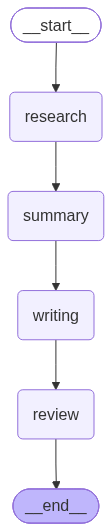

In [31]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

AI agent

In [32]:
state = {
    "topic": "Artificial Intelligence in Healthcare",
    "research_notes": "",
    "summary": "",
    "draft_report": "",
    "final_report": ""
}

result = app.invoke(state)

print(result["final_report"])

# Executive Summary
The integration of Artificial Intelligence (AI) in the healthcare sector is revolutionizing the industry by enhancing patient outcomes, streamlining administrative processes, and reducing errors. With a projected global market value of $630.92 billion by 2033, AI is poised to play a pivotal role in shaping the future of healthcare. This report explores the key applications, benefits, challenges, and future directions of AI in healthcare, providing valuable insights for stakeholders.

# Introduction
The healthcare industry is undergoing a significant transformation with the advent of Artificial Intelligence (AI). AI is being leveraged to automate administrative tasks, minimize human error, and improve patient care. The importance of AI in healthcare lies in its ability to analyze vast amounts of data, identify patterns, and provide insights that inform clinical decisions. As the healthcare sector continues to evolve, understanding the role and potential of AI is cruc